# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [17]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1
Shape: (1000, 2)
Number of rows: 1000
Percentage liked: 50.00%
Percentage not liked: 50.00%


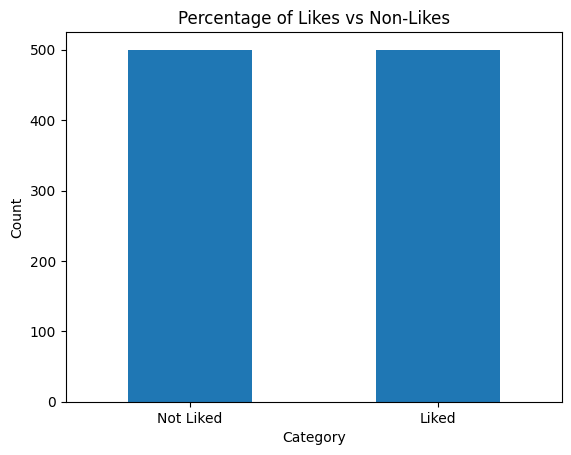

In [18]:
import pandas as pd
import csv
import matplotlib.pyplot as plt

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

# Preview the data
print(df.head())

# Verify all 1,000 rows loaded
print("Shape:", df.shape)
print("Number of rows:", len(df))

# Calculate percentage liked vs not liked
liked_pct = df["Liked"].mean() * 100
not_liked_pct = 100 - liked_pct

print(f"Percentage liked: {liked_pct:.2f}%")
print(f"Percentage not liked: {not_liked_pct:.2f}%")

# Visualization
like_counts = df["Liked"].value_counts().sort_index()
like_counts.index = ["Not Liked", "Liked"]

like_counts.plot(kind="bar")
plt.title("Percentage of Likes vs Non-Likes")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [19]:
import re
import string

# Create a cleaned review column
df["Review_clean"] = df["Review"].str.lower()

# Remove URLs
df["Review_clean"] = df["Review_clean"].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))

# Remove anything that is not letters, numbers, or spaces
df["Review_clean"] = df["Review_clean"].apply(lambda x: re.sub(r'[^a-z0-9\s]', ' ', x))

# Remove extra spaces
df["Review_clean"] = df["Review_clean"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print(df[["Review", "Review_clean"]].head(10))

                                              Review  \
0                           Wow... Loved this place.   
1                                 Crust is not good.   
2          Not tasty and the texture was just nasty.   
3  Stopped by during the late May bank holiday of...   
4  The selection on the menu was great and so wer...   
5     Now I am getting angry and I want my damn pho.   
6              Honeslty it didn't taste THAT fresh.)   
7  The potatoes were like rubber and you could te...   
8                          The fries were great too.   
9                                     A great touch.   

                                        Review_clean  
0                               wow loved this place  
1                                  crust is not good  
2           not tasty and the texture was just nasty  
3  stopped by during the late may bank holiday of...  
4  the selection on the menu was great and so wer...  
5      now i am getting angry and i want my damn pho 

### ✍️ Your Response: 🔧
1. If review junk is left in the model, the results may be less accurate because punctuation, symbols, URLs, and other noise can distract the model from the actual meaning of the review.
2. It could also cause unhelpful tokens to appear as important words, which would weaken both sentiment analysis and topic modeling.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


sentiment_label
Positive    52.8
Negative    24.2
Neutral     23.0
Name: proportion, dtype: float64


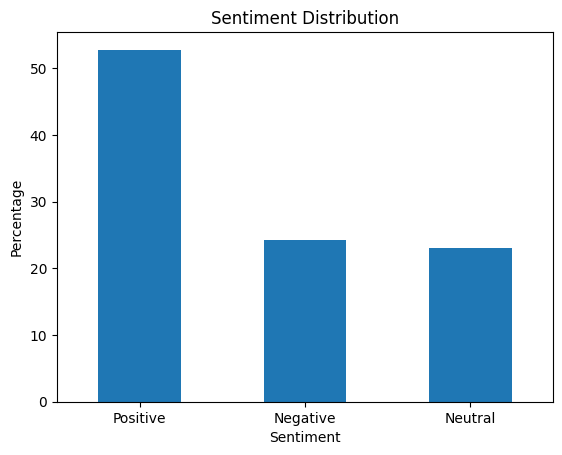

Liked: 50.00%
Not liked: 50.00%


In [20]:
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Get compound sentiment score
df["sentiment_score"] = df["Review_clean"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

# Label sentiment
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(label_sentiment)

# Percentages
sentiment_pct = df["sentiment_label"].value_counts(normalize=True) * 100
print(sentiment_pct)

# Optional display
sentiment_pct.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

# Compare with liked
liked_pct = df["Liked"].mean() * 100
not_liked_pct = 100 - liked_pct

print(f"Liked: {liked_pct:.2f}%")
print(f"Not liked: {not_liked_pct:.2f}%")

### ✍️ Your Response: 🔧
1. The sentiment percentages give more detail than the Liked column because sentiment breaks reviews into positive, neutral, and negative, while Liked only has two values: 1 or 0.
2. From a restaurant owner’s perspective, negative reviews are usually the most important to analyze because they point to problems with food, service, price, or cleanliness that may be hurting customer satisfaction.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [21]:
import nltk
import re

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()

    # tokenize by extracting words/numbers only
    tokens = re.findall(r'\b[a-z0-9]+\b', text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

df["tokens"] = df["Review_clean"].apply(preprocess_text)

# Display first 10 processed reviews
for i, review in enumerate(df["tokens"].head(10), start=1):
    print(f"{i}. {review}")

1. ['wow', 'loved', 'place']
2. ['crust', 'good']
3. ['tasty', 'texture', 'nasty']
4. ['stopped', 'late', 'may', 'bank', 'holiday', 'rick', 'steve', 'recommendation', 'loved']
5. ['selection', 'menu', 'great', 'price']
6. ['getting', 'angry', 'want', 'damn', 'pho']
7. ['honeslty', 'taste', 'fresh']
8. ['potato', 'like', 'rubber', 'could', 'tell', 'made', 'ahead', 'time', 'kept', 'warmer']
9. ['fry', 'great']
10. ['great', 'touch']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### ✍️ Your Response: 🔧
1. A corpora is a collection of language data that NLP tools use for tasks like tokenizing text, removing stopwords, and lemmatizing words.
2. The tokens in the first review, “Wow... Loved this place.”, would be something like: ["wow", "loved", "place"] before lemmatization, and likely ["wow", "loved", "place"] or ["wow", "love", "place"] depending on processing.
3. Lemmatization reduces words to their base form, such as “loved” to “love.” This helps group similar words together and improves the quality of the topic model.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [22]:
!pip install gensim -q

from gensim.corpora import Dictionary

# Create dictionary
dictionary = Dictionary(df["tokens"])

# Create corpus
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

# Display summary
print("Number of unique tokens in dictionary:", len(dictionary))
print("First 10 dictionary items:", list(dictionary.items())[:10])
print("First 5 documents in corpus:")
for doc in corpus[:5]:
    print(doc)

Number of unique tokens in dictionary: 1796
First 10 dictionary items: [(0, 'loved'), (1, 'place'), (2, 'wow'), (3, 'crust'), (4, 'good'), (5, 'nasty'), (6, 'tasty'), (7, 'texture'), (8, 'bank'), (9, 'holiday')]
First 5 documents in corpus:
[(0, 1), (1, 1), (2, 1)]
[(3, 1), (4, 1)]
[(5, 1), (6, 1), (7, 1)]
[(0, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)]
[(16, 1), (17, 1), (18, 1), (19, 1)]


### ✍️ Your Response: 🔧
1. A corpus is the full collection of processed documents represented in a format the model can analyze. It is useful because it shows how often each word appears in each review.
2. A dictionary is different from a corpus because it stores the mapping of each unique word to an ID, while the corpus stores the actual bag-of-words counts for each review.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [23]:
from gensim.models import LdaModel

# Build LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=15)

# Print topics
topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.043*"service" + 0.037*"good" + 0.036*"food" + 0.012*"friendly" + 0.009*"minute" + 0.008*"back" + 0.008*"great" + 0.007*"never" + 0.007*"terrible" + 0.007*"slow"')
(1, '0.046*"place" + 0.025*"back" + 0.023*"go" + 0.017*"time" + 0.013*"like" + 0.013*"would" + 0.012*"food" + 0.008*"star" + 0.007*"never" + 0.006*"going"')
(2, '0.017*"good" + 0.017*"food" + 0.013*"really" + 0.013*"great" + 0.009*"steak" + 0.008*"nice" + 0.008*"flavor" + 0.008*"best" + 0.007*"restaurant" + 0.007*"selection"')
(3, '0.027*"great" + 0.014*"time" + 0.011*"food" + 0.011*"place" + 0.011*"amazing" + 0.008*"delicious" + 0.008*"best" + 0.008*"lunch" + 0.007*"one" + 0.007*"came"')
(4, '0.012*"food" + 0.010*"place" + 0.010*"also" + 0.008*"worst" + 0.008*"price" + 0.008*"experience" + 0.007*"u" + 0.007*"service" + 0.006*"like" + 0.006*"soon"')


### ✍️ Your Response: 🔧
1. You may want to use more than 5 topics when the reviews cover many different themes, such as food quality, service speed, prices, location, cleanliness, and staff behavior.
2. You would know you have too many topics if the topics start looking repetitive, overlap too much, or contain words that are hard to interpret as a clear business theme.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


Topics:
Topic #0: 0.043*"service" + 0.037*"good" + 0.036*"food" + 0.012*"friendly" + 0.009*"minute" + 0.008*"back" + 0.008*"great" + 0.007*"never" + 0.007*"terrible" + 0.007*"slow"
Topic #1: 0.046*"place" + 0.025*"back" + 0.023*"go" + 0.017*"time" + 0.013*"like" + 0.013*"would" + 0.012*"food" + 0.008*"star" + 0.007*"never" + 0.006*"going"
Topic #2: 0.017*"good" + 0.017*"food" + 0.013*"really" + 0.013*"great" + 0.009*"steak" + 0.008*"nice" + 0.008*"flavor" + 0.008*"best" + 0.007*"restaurant" + 0.007*"selection"
Topic #3: 0.027*"great" + 0.014*"time" + 0.011*"food" + 0.011*"place" + 0.011*"amazing" + 0.008*"delicious" + 0.008*"best" + 0.008*"lunch" + 0.007*"one" + 0.007*"came"
Topic #4: 0.012*"food" + 0.010*"place" + 0.010*"also" + 0.008*"worst" + 0.008*"price" + 0.008*"experience" + 0.007*"u" + 0.007*"service" + 0.006*"like" + 0.006*"soon"

Topic Frequency:
dominant_topic
0    208
1    245
2    179
3    169
4    199
Name: count, dtype: int64


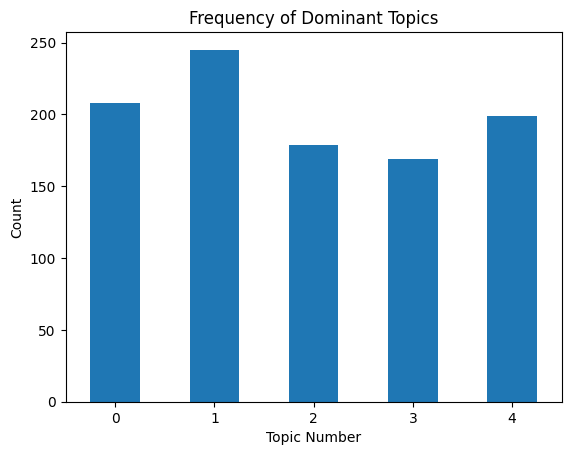


Sentiment by Topic (%):
sentiment_label  Negative  Neutral  Positive
dominant_topic                              
0                   26.92    22.60     50.48
1                   24.49    30.20     45.31
2                   25.14    13.97     60.89
3                   18.34    20.71     60.95
4                   25.13    24.62     50.25


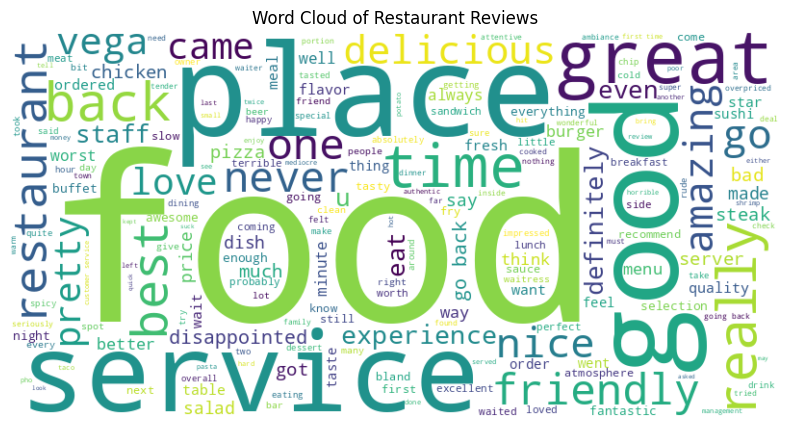

In [24]:
from collections import Counter

# Print topics and top 10 words
print("Topics:")
for topic_num, topic_words in lda_model.print_topics(num_topics=5, num_words=10):
    print(f"Topic #{topic_num}: {topic_words}")

# Assign dominant topic to each review
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0]

df["dominant_topic"] = [get_dominant_topic(bow) for bow in corpus]

# Topic frequency
topic_counts = df["dominant_topic"].value_counts().sort_index()
print("\nTopic Frequency:")
print(topic_counts)

# Visualize topic frequency
topic_counts.plot(kind="bar")
plt.title("Frequency of Dominant Topics")
plt.xlabel("Topic Number")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Sentiment by topic
topic_sentiment = pd.crosstab(df["dominant_topic"], df["sentiment_label"], normalize="index") * 100
print("\nSentiment by Topic (%):")
print(topic_sentiment.round(2))

# Word cloud for all processed text
!pip install wordcloud -q
from wordcloud import WordCloud

all_words = " ".join([" ".join(tokens) for tokens in df["tokens"]])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Restaurant Reviews")
plt.show()

### ✍️ Your Response: 🔧
List your topics and names here:
1. Topic #0 – Food Quality
2. Topic #1 – Customer Service
3. Topic #2 – Restaurant Atmosphere
4. Topic #3 – Price Value
5. Topic #4 – Wait Time

Note: Your exact topics may differ depending on the top words printed by your model, so rename them based on the actual words in your output.

List your topics and names here:

1. Topic #0 – Food Quality
2. Topic #1 – Customer Service
3. Topic #2 – Restaurant Atmosphere
4. Topic #3 – Price Value
5. Topic #4 – Wait Time

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


1. The model helped answer the business question: What main issues and strengths are customers discussing in restaurant reviews?
2. I would recommend that the restaurant focus first on the most common negative topics, especially if they involve service, food quality, or wait times, because those are most likely to reduce customer satisfaction.
3. A benefit of using an LLM is that it can summarize themes in plain language very quickly. A drawback is that it may be less consistent, harder to reproduce exactly, and may miss the transparency of Python-based outputs.
4. Example prompt:
You are a business analyst reviewing 1,000 restaurant customer reviews. Group the reviews into 5 main topics, summarize the tone of each topic as positive, neutral, or negative, and provide business recommendations for improving customer satisfaction. Present the results in a clear table and explain which issues seem most important for the restaurant owner to address first.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [25]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_13_text_analytics.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tr